# 3.4.1 偏导梯度与局部变化

## 学习目标与先修知识

能从单变量导数（derivative）进入偏导数（partial derivative）、梯度（gradient）和多变量链式法则（chain rule），逐列构造 雅可比矩阵（Jacobian matrix），并区分任意点的一阶近似与平衡（equilibrium）附近的线性化（linearization）。

先修：第 2.2 章导数与链式法则；矩阵乘法（matrix multiplication）、方向与平衡。 [复习上一节](../03-耦合、相平面与平衡/02-通道改变与平衡集合.ipynb)。

## 具体问题

当清除能力逐渐饱和，多加一点物质不再带来同样多的清除。两个变量同时参与时，怎样分别量化每个变量对每条变化率的影响？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK = '#008bfb', '#ff0051'

## 初步实验

先计算一个具体情形，再解释这些数是怎样相互制约的。

In [2]:
v,K=1.,2.
for amount in [0,2,10]:
    removal=v*amount/(K+amount)
    slope=v*K/(K+amount)**2
    print(f'A1={amount:g} U: 清除 {removal:.4f} U/T，局部斜率 {slope:.4f} /T')

A1=0 U: 清除 0.0000 U/T，局部斜率 0.5000 /T
A1=2 U: 清除 0.5000 U/T，局部斜率 0.1250 /T
A1=10 U: 清除 0.8333 U/T，局部斜率 0.0139 /T


## 模型假设

两室充分混合，aA1、bA2 是线性交换，室 1 输入（input） u，并以 g(A1)=vA1/(K+A1) 清除，室 2 无外部损失。a=.2/T、b=.1/T、u=.5 U/T、v=1 U/T、K=2 U，均为人工选值。

v 是最大清除速率（U/T），K 是达到半最大速率的所追踪物质总量（tracked amount）（U），不是浓度（concentration）。物理域 A1,A2≥0；数学表达式在 A1=−K 奇异。差分步长只选在所检查点附近、远离奇点且仍为非负量。

## 数学解释与推导

一个标量函数有多个自变量时，偏导数只改变其中一个，其他量固定：
$$\frac{\partial f}{\partial A_1}=\lim_{h\to0}\frac{f(A_1+h,A_2)-f(A_1,A_2)}h.$$
把 $g(A)=v-vK/(K+A)$ 求导得 $g'(A)=vK/(K+A)^2$。v、K 和另一室量在求导时保持不变；斜率（slope）单位为 1/T。饱和意味着 g 趋近 v，而不是总量达到 K 后清除突然停止。

对标量函数 q(x)，各偏导（partial derivative）组成梯度 $\nabla q$。同尺度欧几里得坐标中，小位移 δ 导致 $q(x+\delta)-q(x)\approx\nabla q\cdot\delta$；单位方向中沿梯度增加最快。若 x 随时间变，链式法则给
$$\frac{dq}{dt}=\frac{\partial q}{\partial x_1}\dot x_1+\frac{\partial q}{\partial x_2}\dot x_2=\nabla q\cdot f(x).$$
例如 q=(x1²+x2²)/2，梯度为 x。在 [3,4] U、变化率 [−1,2] U/T 处，dq/dt=5 U²/T。这个数是沿运动的变化率，不是 q 本身。

现在 f 本身有两个分量。雅可比矩阵把各行函数、各列自变量的偏导排列起来：$J_{ij}=\partial f_i/\partial x_j$。当前
$$f=\begin{pmatrix}u-aA_1+bA_2-g(A_1)\\aA_1-bA_2\end{pmatrix},\quad
J=\begin{pmatrix}-a-\frac{vK}{(K+A_1)^2}&b\\a&-b\end{pmatrix}.$$
一阶 Taylor 近似（first-order Taylor approximation）是 $f(x_0+\delta)=f(x_0)+J(x_0)\delta+R(\delta)$。充分光滑时余项的大小在小邻域内为 $O(\|\delta\|^2)$，即受某常数乘扰动平方约束。任意点的常数项不能删；只有 x0 是平衡时 f(x0)=0。

逐列中心差分（central difference） $(f(x+\epsilon e_j)-f(x-\epsilon e_j))/(2\epsilon)$ 用来核对 J，e1=[1,0]、e2=[0,1]。同时增加两个分量得到的是方向变化，无法区分两列。ε 太大会有截断误差（truncation error），太小则可能放大舍入误差（round-off error）；应比较一段合理范围。

## 核心实现

把刚才的关系逐项写入函数。

In [3]:
def nonlinear_rate(state, a, b, u, v, K):
    first, second = state
    return [u-a*first+b*second-v*first/(K+first), a*first-b*second]

def jacobian(state, a, b, v, K):
    slope = v*K/(K+state[0])**2
    return [[-a-slope, b], [a, -b]]

def jacobian_check(state, a, b, u, v, K, epsilon):
    exact = jacobian(state, a, b, v, K)
    numeric = [[0.0, 0.0], [0.0, 0.0]]
    for column in range(2):
        above, below = list(state), list(state)
        above[column] += epsilon
        below[column] -= epsilon
        right = nonlinear_rate(above, a, b, u, v, K)
        left = nonlinear_rate(below, a, b, u, v, K)
        for row in range(2):
            numeric[row][column] = (right[row]-left[row])/(2*epsilon)
    error = max(abs(exact[i][j]-numeric[i][j]) for i in range(2) for j in range(2))
    return exact, error
def gradient_rate(state, rates):
    gradient = list(state)
    return gradient, sum(x*y for x, y in zip(gradient, rates))

## 对照实验

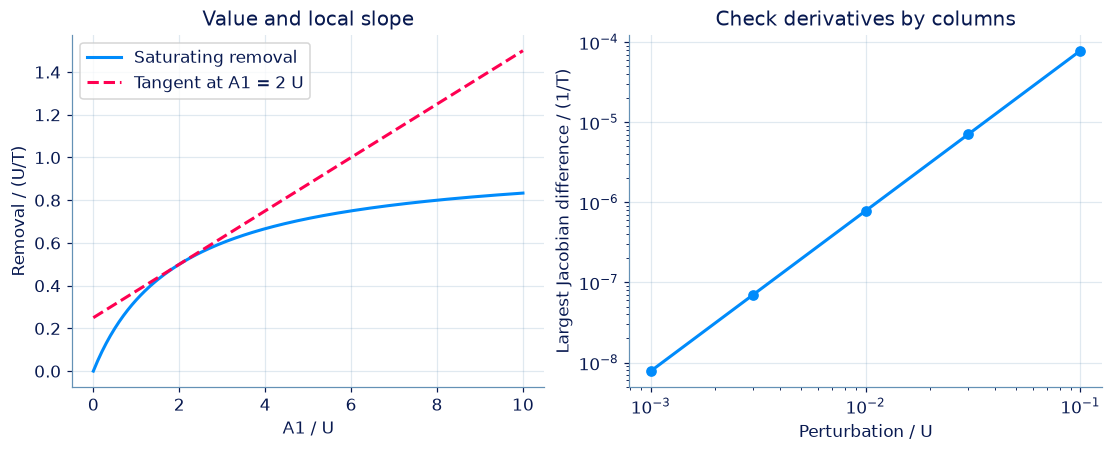

| epsilon / U | 最大矩阵差 / (1/T) |
| --- | --- |
| 0.1 | 7.81739e-05 |
| 0.03 | 7.03165e-06 |
| 0.01 | 7.81255e-07 |
| 0.003 | 7.03125e-08 |
| 0.001 | 7.81246e-09 |

In [4]:
amounts=np.linspace(0,10,201)
fig,axes=plt.subplots(1,2,figsize=(10,4))
axes[0].plot(amounts,amounts/(2+amounts),color=BLUE,label='Saturating removal')
axes[0].plot(amounts,.5+.125*(amounts-2),'--',color=PINK,label='Tangent at A1 = 2 U')
axes[0].set(xlabel='A1 / U',ylabel='Removal / (U/T)',title='Value and local slope');axes[0].legend()
eps=[.1,.03,.01,.003,.001]
errors=[jacobian_check([2,4],.2,.1,.5,1,2,e)[1] for e in eps]
axes[1].loglog(eps,errors,'o-',color=BLUE)
axes[1].set(xlabel='Perturbation / U',ylabel='Largest Jacobian difference / (1/T)',title='Check derivatives by columns');plt.show()
display(Markdown(show_table(['epsilon / U','最大矩阵差 / (1/T)'],zip(eps,errors))))

## 结果解释

切线（tangent line）在 A1=2 附近贴合原清除函数，远处可明显偏离。右图当前差分范围内误差随步长缩小而减小；这检验局部斜率实现，不证明整段线性近似准确。

### 独立核对

中心差分误差还可由有理函数代数精确展开后比较，避免两个实现恰好共享相同导数错误。

In [5]:
matrix,error=jacobian_check([2,4],.2,.1,.5,1,2,.01)
np.testing.assert_allclose(matrix,[[-.325,.1],[.2,-.1]])
assert errors[-1]<errors[0]
assert gradient_rate([3,4],[-1,2])==([3,4],5)
# 清除中心差分的独立代数式：vK / ((K+A1)^2-epsilon^2)
for e,error in zip(eps,errors):
    expected=2/(16-e*e)-.125
    assert math.isclose(error,expected,rel_tol=1e-5,abs_tol=1e-12)
print('Jacobian、链式法则与中心差分误差的独立代数式一致。')

Jacobian、链式法则与中心差分误差的独立代数式一致。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/03-04-多变量变化与局部线性化/explore/)：改变一个条件，观察时间曲线与状态空间（state space）中的运动，再回到本节解释。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：逐列检查局部变化率

模型（model） f1=u−aA1+bA2−vA1/(K+A1)，f2=aA1−bA2。计算指定状态（state）的 雅可比矩阵（Jacobian matrix），并用中心差分（central difference）逐列检查，返回解析矩阵（matrix）和最大元素差。

**函数与代码模板**

```python
def solve(
    state: list[float],
    a: float,
    b: float,
    u: float,
    v: float,
    K: float,
    epsilon: float,
) -> tuple[list[list[float]], float]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 指定 [A1,A2]，不要求恰好平衡（equilibrium）。 | U |
| `a` | `float` | 室 1 到室 2 的交换系数。 | 1/T |
| `b` | `float` | 室 2 到室 1 的交换系数。 | 1/T |
| `u` | `float` | 进入室 1 的输入（input）速率。 | U/T |
| `v` | `float` | 室 1 饱和清除的最大速率。 | U/T |
| `K` | `float` | 清除速率达到 v/2 时的所追踪物质总量（tracked amount）。 | U |
| `epsilon` | `float` | 每次只扰动一个总量分量的幅度。 | U |

**返回值**

按以下顺序返回元组：(matrix, error)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `matrix` | `list[list[float]]` | Jij=∂fi/∂Aj，先行后列。 | 1/T |
| `error` | `float` | 解析与中心差分矩阵逐元素绝对差的最大值。 | 1/T |

**计算规则**

J=[[-a−vK/(K+A1)²,b],[a,−b]]。中心差分第 j 列为 (f(state+epsilon*e_j)−f(state−epsilon*e_j))/(2epsilon)。不对两个分量同时扰动。

**约束与边界**

- 所有数值有限；不修改输入列表。
- 0≤a≤1；0.05≤b≤1；0≤u≤1；0.5≤v,K≤3；state 两项均 0.5—10；1e−3≤epsilon≤0.1。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 指定 [A1,A2]，不要求恰好平衡（equilibrium）。 | [2, 4] | U |
| a | 室 1 到室 2 的交换系数。 | 0.2 | 1/T |
| b | 室 2 到室 1 的交换系数。 | 0.1 | 1/T |
| u | 进入室 1 的输入（input）速率。 | 0.5 | U/T |
| v | 室 1 饱和清除的最大速率。 | 1 | U/T |
| K | 清除速率达到 v/2 时的所追踪物质总量（tracked amount）。 | 2 | U |
| epsilon | 每次只扰动一个总量分量的幅度。 | 0.01 | U |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [2, 4]
a = 0.2
b = 0.1
u = 0.5
v = 1
K = 2
epsilon = 0.01

result = solve(state, a, b, u, v, K, epsilon)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| matrix | Jij=∂fi/∂Aj，先行后列。 | [[-0.325, 0.1], [0.2, -0.1]] | 1/T |
| error | 解析与中心差分矩阵逐元素绝对差的最大值。 | ≈ 7.812549e-07 | 1/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([[-0.325, 0.1], [0.2, -0.1]],
                   7.812548805108399e-07)
```

**样例解释**

在 [2,4] 清除导数（derivative）为 1×2/(2+2)²=0.125 /T，所以第一行是 [−0.325,0.1]；有限差分（finite difference）只产生很小的近似误差。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：逐列检查局部变化率](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-jacobian)

### 第 2 题 · Python 计算题：沿轨迹计算平方距离的变化

两个状态（state）分量单位均为 U。定义 g(x)=1/2(x1²+x2²)，当前变化率已给出。返回 g 的梯度（gradient），以及沿轨迹（trajectory）的变化率。

**函数与代码模板**

```python
def solve(
    state: list[float],
    rates: list[float],
) -> tuple[list[float], float]:
    # 根据题意计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `state` | `list[float]` | 当前二维状态。 | U |
| `rates` | `list[float]` | 当前 [x1′,x2′]。 | U/T |

**返回值**

按以下顺序返回元组：(gradient, change)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `gradient` | `list[float]` | [∂g/∂x1,∂g/∂x2]。 | U |
| `change` | `float` | dg/dt。 | U²/T |

**计算规则**

gradient=[x1,x2]；dg/dt=gradient[0]*rates[0]+gradient[1]*rates[1]。

**约束与边界**

- 所有数值有限；不修改输入（input）列表。
- 两列表长度为 2；各分量绝对值≤20。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| state | 当前二维状态。 | [3, 4] | U |
| rates | 当前 [x1′,x2′]。 | [-1, 2] | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
state = [3, 4]
rates = [-1, 2]

result = solve(state, rates)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| gradient | [∂g/∂x1,∂g/∂x2]。 | [3, 4] | U |
| change | dg/dt。 | 5 | U²/T |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([3, 4], 5)
```

**样例解释**

梯度为 [3,4] U，沿轨迹变化率为 3×(−1)+4×2=5 U²/T。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：沿轨迹计算平方距离的变化](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-chain-rate)

### 第 3 题 · 多项选择题：偏导数固定什么

计算 f1 对 A1 的偏导（partial derivative）时，以下哪些操作正确？

- **A.** 保持 A2 与模型（model）参数（parameter）不变。
- **B.** 把 A2 同时改为 A2+epsilon。
- **C.** 对 vA1/(K+A1) 求导得到 vK/(K+A1)²。
- **D.** 结果单位为 (U/T)/U=1/T。

[作答：偏导数固定什么](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-partial-meaning)

### 第 4 题 · 单项选择题：不是平衡时还缺哪一项

在任意点 x0 附近，一阶 Taylor 近似 f(x0+δ) 应写成？

- **A.** J(x0)δ，总是没有常数项。
- **B.** f(x0)+J(x0)δ。
- **C.** J(x0)x0，与 δ 无关。
- **D.** f(δ)，因为只是改了名字。

[作答：不是平衡时还缺哪一项](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-affine-approximation)

### 第 5 题 · 多项选择题：差分一致性证明了什么

解析 雅可比矩阵（Jacobian matrix） 与中心差分（central difference）在一个点十分接近。哪些结论可以得出？

- **A.** 在所测点、扰动和精度下，两种导数（derivative）计算一致。
- **B.** 原非线性模型（model）必定真实描述人体。
- **C.** 任意大扰动都能由这一个矩阵（matrix）准确预测。
- **D.** 仍需要不同扰动幅度和轨迹（trajectory）误差对照。

[作答：差分一致性证明了什么](http://127.0.0.1:8000/chapters/03-04-%E5%A4%9A%E5%8F%98%E9%87%8F%E5%8F%98%E5%8C%96%E4%B8%8E%E5%B1%80%E9%83%A8%E7%BA%BF%E6%80%A7%E5%8C%96/practice/?question=p03-difference-proof)

**进一步阅读**

[MIT 多变量微积分](https://ocw.mit.edu/courses/18-02sc-multivariable-calculus-fall-2010/)：偏导、梯度、切平面与链式法则。 [MIT 一阶系统课程](https://ocw.mit.edu/courses/18-03sc-differential-equations-fall-2011/pages/unit-iv-first-order-systems/)：矩阵方法、矩阵指数、相图与线性化。